Для аналізу та побудови моделі був взятий датасет по car_crashes.

### EDA

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('car_crashes.csv')

df.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   total           51 non-null     float64
 1   speeding        51 non-null     float64
 2   alcohol         51 non-null     float64
 3   not_distracted  51 non-null     float64
 4   no_previous     51 non-null     float64
 5   ins_premium     51 non-null     float64
 6   ins_losses      51 non-null     float64
 7   abbrev          51 non-null     object 
dtypes: float64(7), object(1)
memory usage: 3.3+ KB


In [4]:
df.describe()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000
mean,15.790196,4.998196,4.886784,13.573176,14.004882,886.957647,134.493137
std,4.122002,2.017747,1.729133,4.508977,3.764672,178.296285,24.835922
min,5.900000,1.792000,1.593000,1.760000,5.900000,641.960000,82.750000
25%,12.750000,3.766500,3.894000,10.478000,11.348000,768.430000,114.645000
50%,15.600000,4.608000,4.554000,13.857000,13.775000,858.970000,136.050000
75%,18.500000,6.439000,5.604000,16.140000,16.755000,1007.945000,151.870000
max,23.900000,9.450000,10.038000,23.661000,21.280000,1301.520000,194.780000


Набір даних складається з 51 рядка (статистика по штатах США) та 8 колонок. Пропущених значень (Null/NaN) немає. Дані виявилися чистими. Усі числові ознаки мають коректний тип даних float64, а назви штатів — object. Додаткову очистку проводити не треба.

<Figure size 1000x800 with 0 Axes>

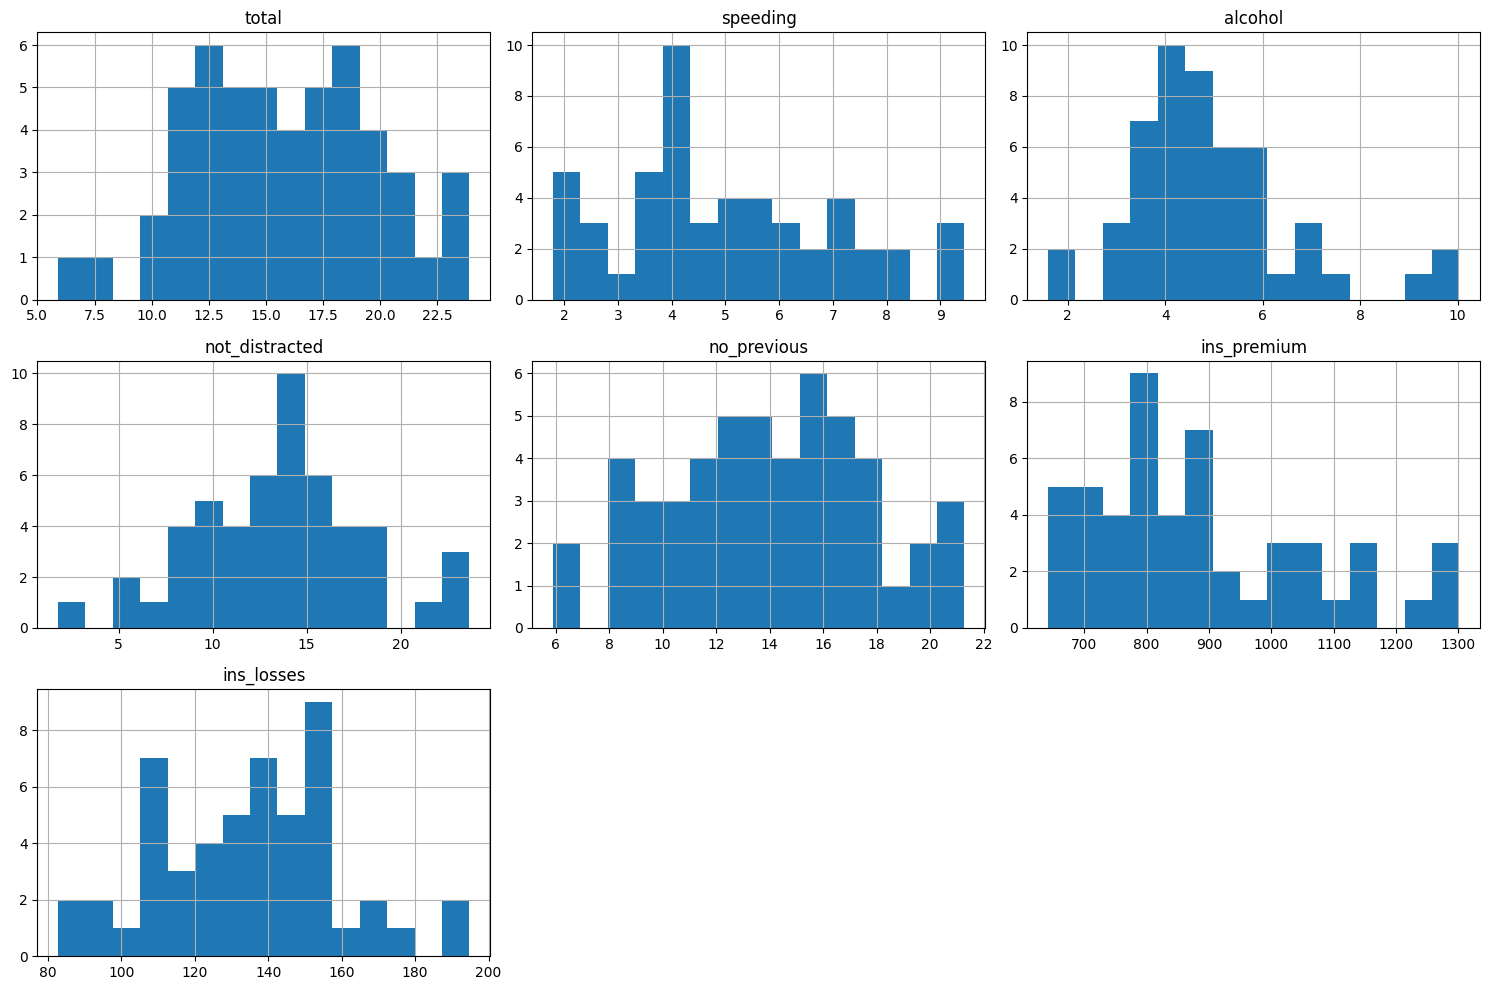

In [6]:
# Basic EDA plots
plt.figure(figsize=(10, 8))
df.hist(bins=15, figsize=(15, 10))
plt.tight_layout()
plt.show();

Більшість ознак (швидкість, алкоголь, відволікання за кермом) мають розподіл, що нагадує нормальний, з невеликою асиметрією. Це означає, що критичних аномалій чи екстремальних викидів у даних немає, вони добре збалансовані та повністю готові до моделювання без складних математичних трансформацій.

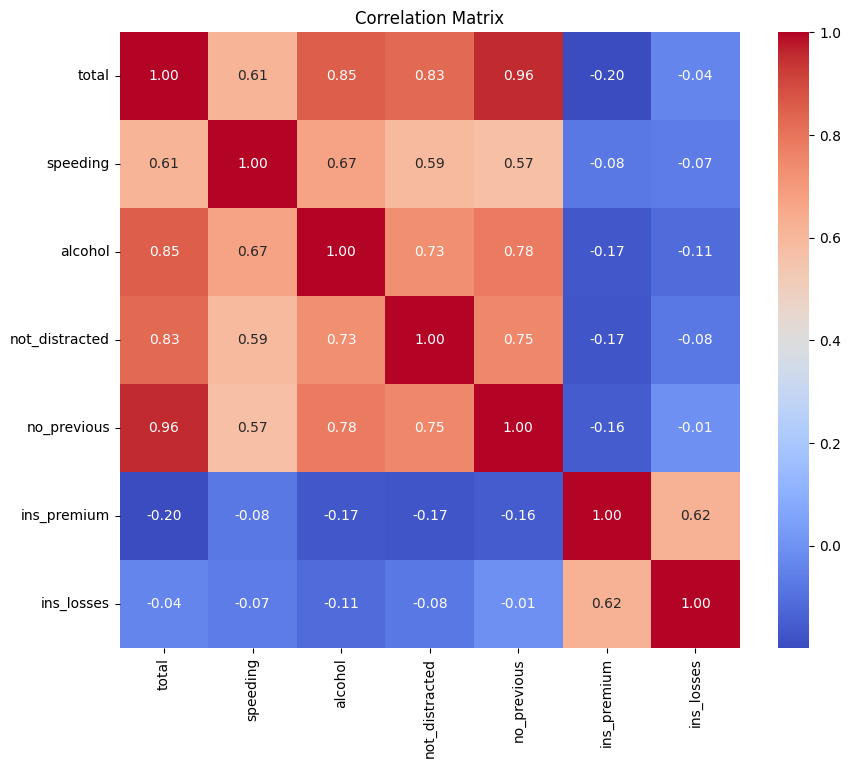

In [7]:
numeric_cols = df.select_dtypes(include=['float64'])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show();

На тепловій карті чітко виділяються два незалежні блоки. Перший — це фактори самої аварійності (алкоголь, швидкість, перша ДТП тощо), які дуже сильно корелюють між собою та із загальною кількістю аварій. Другий — фінансові показники страхових компаній, які живуть "своїм життям" і майже не впливають на статистику ДТП.

Через таку високу залежність (мультиколінеарність) змінних у першій групі, ми по суті можемо застосувати PCA (метод головних компонент) і стиснути весь цей датасет всього до 2 ключових фічей (наприклад, аварійна поведінка та страхові витрати), взагалі не втративши при цьому важливої інформації.

Найбільший вплив на загальну кількість аварій (total) мають такі фактори, як водіння в нетверезому стані (alcohol) та водії, що вперше потрапили в ДТП (no_previous), кореляція з якими перевищує 0.85. Натомість змінні вартості страхування та збитків (ins_premium, ins_losses) мають слабкий зв'язок із реальною кількістю аварій. Загалом, завдяки сильним лінійним залежностям між предикторами, цей набір даних є ідеальним для побудови прогнозних моделей на основі лінійної регресії.

### Тренування моделі
Тут PCA все-таки не застосовуватимемо, оскільки ознак небагато, а вибірка даних маленька. PCA тільки негативно вплине на метрики лінійної регресії.

In [8]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

X = df[['speeding', 'alcohol', 'not_distracted', 'no_previous', 'ins_premium', 'ins_losses']]
y = df['total']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('linreg', LinearRegression())
])

# Hyperparameter grid
param_grid = {
    'linreg__fit_intercept': [True, False]
}

# GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
best_params = grid_search.best_params_

In [10]:
print(f"Best params: {best_params}")
print(f"MSE: {mse:.4f}")
print(f"R^2: {r2:.4f}")

Best params: {'linreg__fit_intercept': True}
MSE: 2.1862
R^2: 0.8791


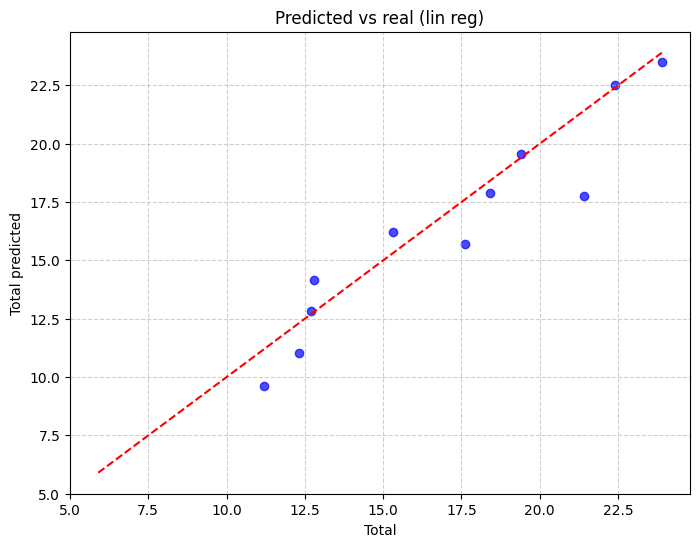

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.xlabel("Total")
plt.ylabel("Total predicted")
plt.title("Predicted vs real (lin reg)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

/usr/local/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


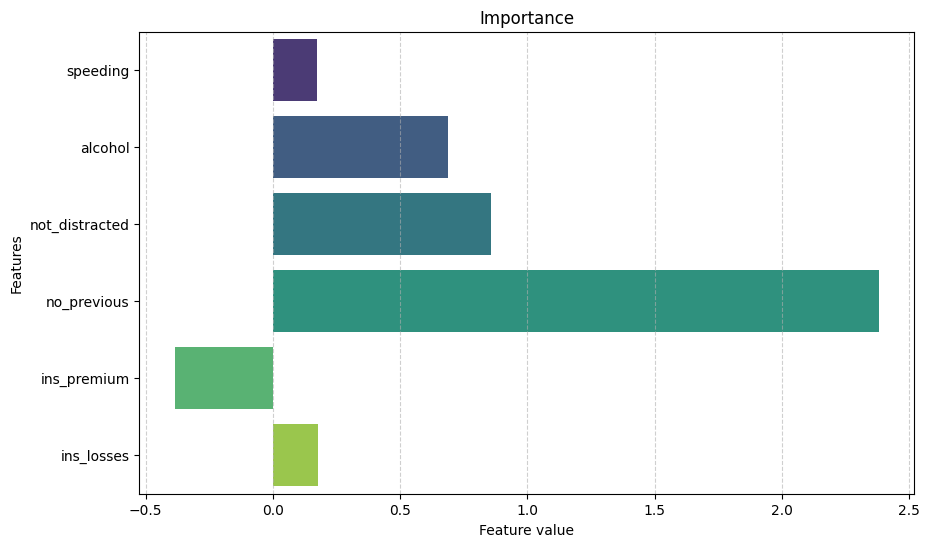

In [17]:
# Feature importance

coefficients = best_model.named_steps['linreg'].coef_
feature_names = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=coefficients, y=feature_names, palette='viridis')
plt.xlabel("Feature value")
plt.ylabel("Features")
plt.title("Importance")
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.show()

Побудована модель лінійної регресії продемонструвала відмінний результат із коефіцієнтом детермінації близько 0.88, успішно пояснюючи 88% варіативності аварійності між штатами.

Середньоквадратична помилка (MSE $\approx$ 2.18) є доволі низькою, що підтверджує здатність алгоритму робити надійні прогнози з мінімальними відхиленнями від фактичних значень.

Хоча датасет із 51 запису є замалим але, його розміру виявилося цілком достатньо для виявлення лінійних закономірностей класичною регресією для цієї задачі.

Найважливішими факторами для прогнозу стали поведінкові індикатори водіїв, зокрема водіння в нетверезому стані, відсутність попереднього досвіду та перевищення швидкості.

Водночас фінансові метрики страхових компаній (премії та виплати) виявилися статистичним шумом, який практично не має прямого впливу на реальну кількість ДТП.